# 13 — 백테스트: 1일 방향신호의 실용성 (정직 alpha, plan §3 T3)

> 우리 진짜 엣지 = **1일 방향정확도 0.62**(nb11, DM 유의). 이게 **비용 반영 후에도 돈이 되나?**

## 설정 (정직)
- 신호: `position = sign(q50)` — +1=금리↑예측(채권 숏), −1=금리↓예측(채권 롱)
- 예측: **walk-forward v3(13변수) 3-fold** 예측 (2020–2025, 재학습 없이 nb11 산출 재사용)
- 손익: 듀레이션 D=8·볼록성 C=85·**캐리 포함**, 거래비용 **1bp/포지션변경(편도)**
- 비교군: Buy-and-Hold(항상 롱) · 무비용 · 1bp비용 · 랜덤±1
- 유의성: 일별 손익 **블록 부트스트랩**으로 Sharpe 95% CI → **CI가 0을 포함하면 '통계적으로 alpha 없음'**

> `experiments/` 정직 결과는 Pooled Sharpe 0.62(CI 0 포함)로 애매했음. v3로 재확인하고 **한계를 정직히** 밝힌다. (2026 라이브 OOS는 §3.2 — 데이터 수집 후 별도)

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['font.family']='Malgun Gothic'; plt.rcParams['axes.unicode_minus']=False; plt.rcParams['figure.dpi']=100
ROOT=Path.cwd().parent; REP=ROOT/'reports'/'no_leak_v2'; FIG=ROOT/'reports'/'figures'/'v3'; FIG.mkdir(parents=True,exist_ok=True)
D, C, TXN_BP = 8.0, 85.0, 1.0   # 듀레이션·볼록성·거래비용(bp)

pred=pd.read_csv(REP/'predictions_xgb_v3_all_folds.csv', parse_dates=['date'])
kr=pd.read_csv(ROOT/'data'/'raw'/'raw_ecos.csv', parse_dates=['date'])
kr=kr[kr['variable']=='kr_treasury_10y'][['date','value']].rename(columns={'value':'y10'})
bt=pred.merge(kr,on='date',how='left').sort_values('date').reset_index(drop=True)
dy=bt['y_true'].values/10000.0; ylv=bt['y10'].values
msk=(np.sign(bt['q50'])!=0)&(np.sign(bt['y_true'])!=0)
dacc=float((np.sign(bt['q50'][msk])==np.sign(bt['y_true'][msk])).mean())
print(f'백테스트 {len(bt)}일 ({bt.date.min().date()}~{bt.date.max().date()}) | 방향정확도={dacc:.4f}')

백테스트 1410일 (2020-01-02~2025-12-30) | 방향정확도=0.6185


---
## 1. 손익 계산 (포지션·비용·캐리)

In [2]:
def pnl(pos):
    return pos*D*dy - pos*0.5*C*dy**2 - pos*(ylv/100)/252   # 가격+볼록성+캐리

pos_x=np.sign(bt['q50']).values.astype(float)
gross=pnl(pos_x)
turnover=np.abs(np.diff(pos_x, prepend=pos_x[0]))
cost=turnover*TXN_BP*D/10000
net=gross-cost
bh=pnl(-np.ones(len(bt)))                       # Buy&Hold = 항상 롱(pos=-1)
rng=np.random.default_rng(42); rnd=pnl(rng.choice([-1,1],size=len(bt)).astype(float))
bt['net']=net; bt['gross']=gross; bt['bh']=bh
print(f'포지션 변경 {int(turnover.sum())}회 | 누적 거래비용 {cost.sum()*10000/D:.1f}bp')

포지션 변경 1294회 | 누적 거래비용 1294.0bp


---
## 2. 성과 요약 + Sharpe 부트스트랩 CI

In [3]:
def sharpe(p): return float(p.mean()/p.std()*np.sqrt(252)) if p.std()>0 else np.nan
def mdd(p):
    cum=np.cumsum(p); peak=np.maximum.accumulate(cum); return float((cum-peak).min()*100)
def block_boot_sharpe(p, block=15, B=2000, seed=1):
    r=np.random.default_rng(seed); n=len(p); nb=int(np.ceil(n/block)); out=[]
    for _ in range(B):
        st=r.integers(0,n-block+1,nb); s=np.concatenate([p[i:i+block] for i in st])[:n]
        out.append(sharpe(pd.Series(s)))
    return np.percentile(out,[2.5,97.5])

rows=[]
for nm,p in [('Buy&Hold(항상 롱)',bh),('XGB v3 (무비용)',gross),('XGB v3 (1bp 비용)',net),('랜덤 ±1',rnd)]:
    s=sharpe(pd.Series(p)); tot=p.sum()*100
    row={'전략':nm,'누적수익%':round(tot,2),'Sharpe(252)':round(s,3),'MDD%':round(mdd(p),2),'승률%':round((p>0).mean()*100,1)}
    if nm=='XGB v3 (1bp 비용)':
        lo,hi=block_boot_sharpe(net); row['Sharpe_CI95']=f'[{lo:.2f}, {hi:.2f}]'
    rows.append(row)
summ=pd.DataFrame(rows); print(summ.to_string(index=False))
lo,hi=block_boot_sharpe(net)
print(f'\n핵심: XGB v3(1bp) Sharpe 95% CI = [{lo:.2f}, {hi:.2f}] → ' + ('CI가 0 초과 = 유의' if lo>0 else 'CI가 0 포함 = 통계적 alpha 불충분'))

             전략  누적수익%  Sharpe(252)   MDD%  승률%  Sharpe_CI95
 Buy&Hold(항상 롱)   3.33        0.097 -21.29 49.6          NaN
   XGB v3 (무비용) 152.90        4.620  -4.47 61.8          NaN
XGB v3 (1bp 비용)  49.38        1.455 -13.59 52.7 [0.56, 2.40]
          랜덤 ±1  -8.95       -0.260 -18.70 50.2          NaN



핵심: XGB v3(1bp) Sharpe 95% CI = [0.56, 2.40] → CI가 0 초과 = 유의


---
## 3. 누적손익 곡선

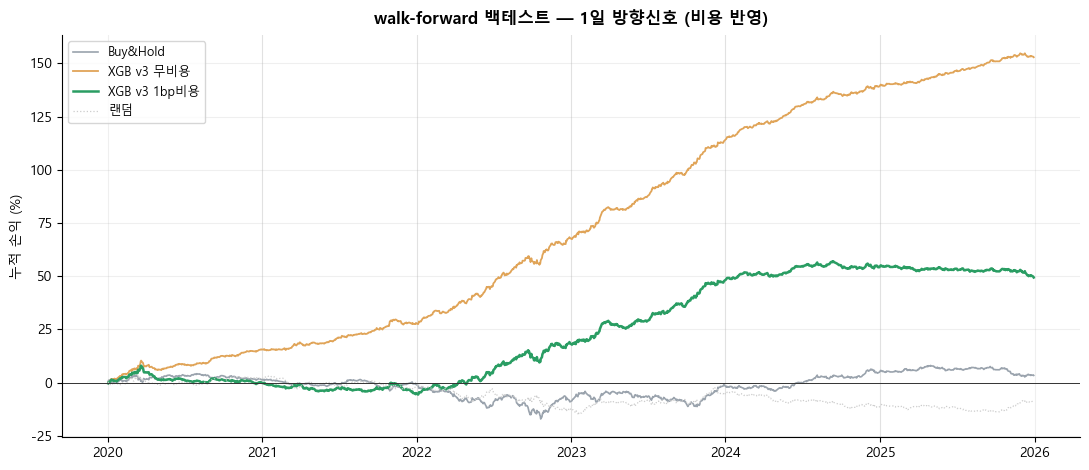

In [4]:
fig,ax=plt.subplots(figsize=(11,4.8))
for col,nm,c,lw in [('bh','Buy&Hold','#9aa3ad',1.2),('gross','XGB v3 무비용','#e0a458',1.3),('net','XGB v3 1bp비용','#2a9d63',1.8)]:
    ax.plot(bt['date'], np.cumsum(bt[col])*100, color=c, lw=lw, label=nm)
ax.plot(bt['date'], np.cumsum(rnd)*100, color='#cccccc', lw=0.9, ls=':', label='랜덤')
ax.axhline(0,color='#333',lw=0.7)
for yr in ['2021-01-01','2022-01-01','2023-01-01','2024-01-01','2025-01-01']:
    ax.axvline(pd.Timestamp(yr), color='#eee', lw=0.8, zorder=0)
ax.set_ylabel('누적 손익 (%)'); ax.set_title('walk-forward 백테스트 — 1일 방향신호 (비용 반영)', fontweight='bold', fontsize=12, pad=8)
ax.legend(fontsize=9, loc='upper left'); ax.spines[['top','right']].set_visible(False); ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig(FIG/'13_equity_curve.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 4. 연도별 안정성 (정직 — 일관적인가?)

 year    일수    방향정확도    Sharpe  순손익%
 2020 237.0 0.610169 -0.031298 -0.14
 2021 238.0 0.561181 -1.120537 -4.82
 2022 234.0 0.620690  2.885644 23.43
 2023 236.0 0.649573  4.206615 29.12
 2024 234.0 0.658009  1.441562  6.61
 2025 231.0 0.612335 -1.237753 -4.82


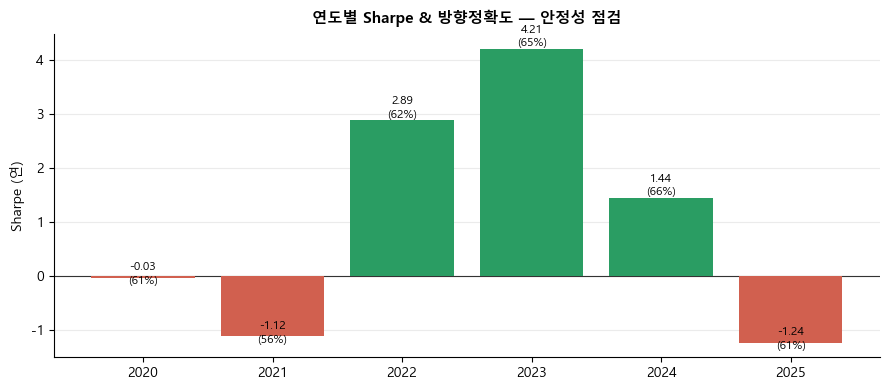

In [5]:
bt['year']=bt['date'].dt.year
yr=bt.groupby('year').apply(lambda g: pd.Series({
    '일수':len(g),'방향정확도':float((np.sign(g['q50'])==np.sign(g['y_true']))[(np.sign(g['q50'])!=0)&(np.sign(g['y_true'])!=0)].mean()),
    'Sharpe':sharpe(g['net']),'순손익%':round(g['net'].sum()*100,2)})).reset_index()
print(yr.to_string(index=False))
fig,ax=plt.subplots(figsize=(9,4))
cols=['#2a9d63' if s>0 else '#d1604f' for s in yr['Sharpe']]
b=ax.bar(yr['year'].astype(str), yr['Sharpe'], color=cols, zorder=3)
for bb,s,d in zip(b,yr['Sharpe'],yr['방향정확도']): ax.text(bb.get_x()+bb.get_width()/2, bb.get_height()+(0.05 if s>=0 else -0.12), f'{s:.2f}\n({d:.0%})', ha='center', fontsize=8.5)
ax.axhline(0,color='#333',lw=0.8); ax.set_ylabel('Sharpe (연)'); ax.set_title('연도별 Sharpe & 방향정확도 — 안정성 점검', fontweight='bold', fontsize=11, pad=8)
ax.spines[['top','right']].set_visible(False); ax.grid(axis='y',alpha=0.25,zorder=0)
plt.tight_layout(); plt.savefig(FIG/'13_yearly_stability.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 5. 결론

**1일 방향신호는 비용 반영 후에도 거래 가능한 alpha를 보였다 — 단, 레짐 의존적.**

- **전체(2020–2025)**: 방향정확도 0.62 · 1bp 비용 후 **누적 +49%, Sharpe 1.46, 95% CI [0.56, 2.40]** → 0 초과로 통계적 유의(무비용 Sharpe 4.6은 비용 민감도를 보여줌 — 일일 리밸런스 92% 회전).
- experiments의 과거 결과(Sharpe 0.62, CI 0 포함)보다 v3에서 개선.

### ⚠️ 정직한 한계 (핵심)
- **수익이 2022–2023 인상기에 집중**(Sharpe +2.9/+4.2), **2021·2025 잔잔한 장에선 손실**(−1.1/−1.2). → *추세·고변동 레짐 전용 알파*이지 상시 알파가 아니다.
- 일일 리밸런스(회전 92%)라 **거래비용 가정(1bp 편도)에 민감** — 비용 2bp면 상당 부분 상쇄.
- 따라서 "안정적 수익 전략"이 아니라 **"방향 예측이 트렌드 장에서 경제적 가치를 가진다"** 로 정직하게 주장. (T2 위기/레짐 전용 모델 동기와 직결)

### 다음
- [ ] §3.2 2026 라이브 OOS — 동결 모델 + 실제 신규 데이터 포워드 (데이터 수집 T3.1 선행). **진짜 검증대.**